# Average Shortest Paths Window-Exit Proportion Optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from ts2vg import HorizontalVG, NaturalVG
import datetime as dt
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

##### Data Preparation

In [3]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
START_BALANCE = 1000
EXIT_PROP = 1.0
LOOKBACK=7
SPLIT_DATE = "2021-01-01"

In [3]:
data = pd.read_csv('./data/crsp_dsf.csv')
data[DATE_COL] = data[DATE_COL].astype('datetime64[s]')
data = data.dropna(subset='dlyclose').reset_index(drop=True)
data['dlyvol'] = data['dlyvol'].fillna(0)
data['tot_shares'] = (data['dlycap'] / data['dlyprc']).round(0)
data[NUM_COL] = data['dlyclose'] * data['tot_shares'] / 1000000
training_tickers = pd.read_csv("./data/training_tickers.csv")
data = pd.merge(left=data, right=training_tickers, on=[TICKER_COL1, TICKER_COL2])
tickers = data[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True).values
data.head()

,permno,hdrcusip,permco,siccd,nasdissuno,yyyymmdd,sharetype,securitytype,securitysubtype,usincflg,...,dlymmcnt,dlyprcvol,dlycumfacpr,dlycumfacshr,cusip,ticker,exchangetier,shrout,tot_shares,true_prc
0,10026,46603210,7976,2052,10433,20100104,NS,EQTY,COM,Y,...,29.0,1923931.8,1.0,1.0,46603210,JJSF,Q,18374,18374.0,0.738635
1,10032,72913210,7980,3672,10437,20100104,NS,EQTY,COM,Y,...,46.0,3580667.5,1.0,1.0,72913210,PLXS,Q,39649,39649.0,1.166077
2,10138,74144T10,8087,6282,10609,20100104,NS,EQTY,COM,Y,...,54.0,131526252.8,1.0,1.0,74144T10,TROW,Q,258534,258534.0,14.064250
3,10180,00972810,9743,2834,12980,20100104,NS,EQTY,COM,Y,...,38.0,402057.5,1.0,1.0,00972810,AKRX,G,90390,90390.0,0.169029
4,10200,75991610,8135,2836,10673,20100104,NS,EQTY,COM,Y,...,36.0,2033982.4,1.0,1.0,75991610,RGEN,G,30762,30762.0,0.124278


##### Helper Functions

###### Average Shortest Paths

In [4]:
### avsp ==> Average Shortest Path
def ts2vg_shortest_path_features(arr, lookback):
    avsp_p = np.zeros(len(arr))
    avsp_n = np.zeros(len(arr))

    avsp_p[:] = np.nan
    avsp_n[:] = np.nan

    for i in range(lookback, len(arr)):
        dat = arr[i - lookback + 1: i+1]

        pos = NaturalVG()
        pos.build(dat)

        neg = NaturalVG()
        neg.build(-dat)

        neg = neg.as_networkx()
        pos = pos.as_networkx()
        
        avsp_p[i] = nx.average_shortest_path_length(pos)
        avsp_n[i] = nx.average_shortest_path_length(neg)

    return avsp_p, avsp_n

In [5]:
def get_avsp_one_stock(ticker, data=data, lookback=7, num_col=NUM_COL, ret_cols = [DATE_COL, TICKER_COL1, TICKER_COL2, 'pos', 'neg']):
    df = data[(data[TICKER_COL1] == ticker[0]) & (data[TICKER_COL2] == ticker[1])].copy()
    df = df.sort_values(DATE_COL).set_index(DATE_COL)
    arr = df[num_col].to_numpy()

    ### Get shortest path features
    pos, neg = ts2vg_shortest_path_features(arr, lookback)

    df["pos"] = pos
    df["neg"] = neg
    
    cols = ret_cols + [num_col]
    df = df.reset_index()[cols]

    return df.dropna(subset=cols).reset_index(drop=True)


In [6]:
def get_all_avsp(tickers=tickers, data=data, lookback=7, num_col=NUM_COL, ret_cols = [DATE_COL, TICKER_COL1, TICKER_COL2, 'pos', 'neg']):
    all_avsp = pd.DataFrame()
    
    for t in tickers:
        avsp_df = get_avsp_one_stock(ticker=t, data=data, lookback=lookback, num_col=num_col, ret_cols=ret_cols)
        
        if len(all_avsp) == 0:
            all_avsp = avsp_df.copy()
        else:
            all_avsp = pd.concat([all_avsp, avsp_df])
    return all_avsp

###### Trading Strategy

In [7]:
def avsp_simple_strat_single(df, curr_b=1000, exit_prop=1.0, num_col=NUM_COL):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():

        pos = row['pos']
        neg = row['neg']
        num = row[num_col]

        ### Buy signal
        if pos >= neg:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [8]:
def avsp_simple_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP, num_col=NUM_COL):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[(data[TICKER_COL1] == t[0]) & (data[TICKER_COL2] == t[1])].reset_index(drop=True)
        returns = avsp_simple_strat_single(df, curr_b=curr_b, exit_prop=exit_prop, num_col=num_col)
        start_vol = START_BALANCE / df[num_col].iloc[0]
        hold_ret = start_vol * df[num_col].values
        stg_df = (
            df[[TICKER_COL1, TICKER_COL2, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    
    return ret_df

##### Fine-Tuner Development

In [9]:
def fine_tuner_single(data=data, tickers=tickers, lookback=7, exit_prop=EXIT_PROP,
                      curr_b=START_BALANCE, num_col=NUM_COL, 
                      ret_cols = [DATE_COL, TICKER_COL1, TICKER_COL2, 'dlyclose', 'tot_shares', 'pos', 'neg']):
    all_avsp = get_all_avsp(data=data, tickers=tickers, lookback=lookback,
                            num_col=num_col, ret_cols=ret_cols)
    ret_df = avsp_simple_strat(data=all_avsp, tickers=tickers, curr_b=curr_b,
                               exit_prop=exit_prop, num_col=num_col)
    return ret_df

In [10]:
def fine_tune(lookbacks, exit_props, data=data, tickers=tickers, curr_b=START_BALANCE, num_col=NUM_COL, 
                ret_cols = [DATE_COL, TICKER_COL1, TICKER_COL2, 'dlyclose', 'tot_shares', 'pos', 'neg']):
    all_rets_df = pd.DataFrame()
    for l in lookbacks:
        for p in exit_props:
            ret_df = fine_tuner_single(data=data, tickers=tickers, lookback=l, exit_prop=p,
                                       curr_b=curr_b, num_col=num_col, ret_cols = ret_cols)
            ret_df['lookback'] = np.ones(len(ret_df)) * l
            ret_df['exit_prop'] = np.ones(len(ret_df)) * p
            if len(all_rets_df) == 0:
                all_rets_df = ret_df.copy()
            else:
                all_rets_df = pd.concat([all_rets_df, ret_df])
    
    return all_rets_df     

In [7]:
# lookbacks = range(3, 15, 2)
# exit_props = [0.25, 0.5, 0.75, 1]

# all_rets_df = fine_tune(lookbacks, exit_props)
# all_rets_df.to_csv(f"./data/window_exit_props_optimize_returns.csv", index=False)

In [4]:
lookbacks = range(3, 15, 2)
exit_props = [0.25, 0.5, 0.75, 1]

all_rets_df = pd.read_csv(f"./data/window_exit_props_optimize_returns.csv")
all_rets_df[DATE_COL] = pd.to_datetime(all_rets_df[DATE_COL])
all_rets_df = all_rets_df[all_rets_df[DATE_COL] < SPLIT_DATE]
verison_map = all_rets_df[['lookback', 'exit_prop']].drop_duplicates().reset_index(drop=True).reset_index()
all_rets_df = pd.merge(left=all_rets_df, right=verison_map, on=['lookback', 'exit_prop'])
all_rets_df.head()

,permno,ticker,dlycaldt,strat_ret,hold_ret,lookback,exit_prop,index
0,10026,JJSF,2010-01-07,1000.000000,1000.000000,3.0,0.25,0
1,10026,JJSF,2010-01-08,1000.000000,1003.691983,3.0,0.25,0
2,10026,JJSF,2010-01-11,994.482396,998.154008,3.0,0.25,0
3,10026,JJSF,2010-01-12,1007.094062,1010.812236,3.0,0.25,0
4,10026,JJSF,2010-01-13,1024.829217,1034.546414,3.0,0.25,0


In [5]:
plot_df = all_rets_df.groupby(by=[DATE_COL, 'lookback', 'exit_prop']).agg({"strat_ret" : "sum", "hold_ret" : "sum"}).reset_index()

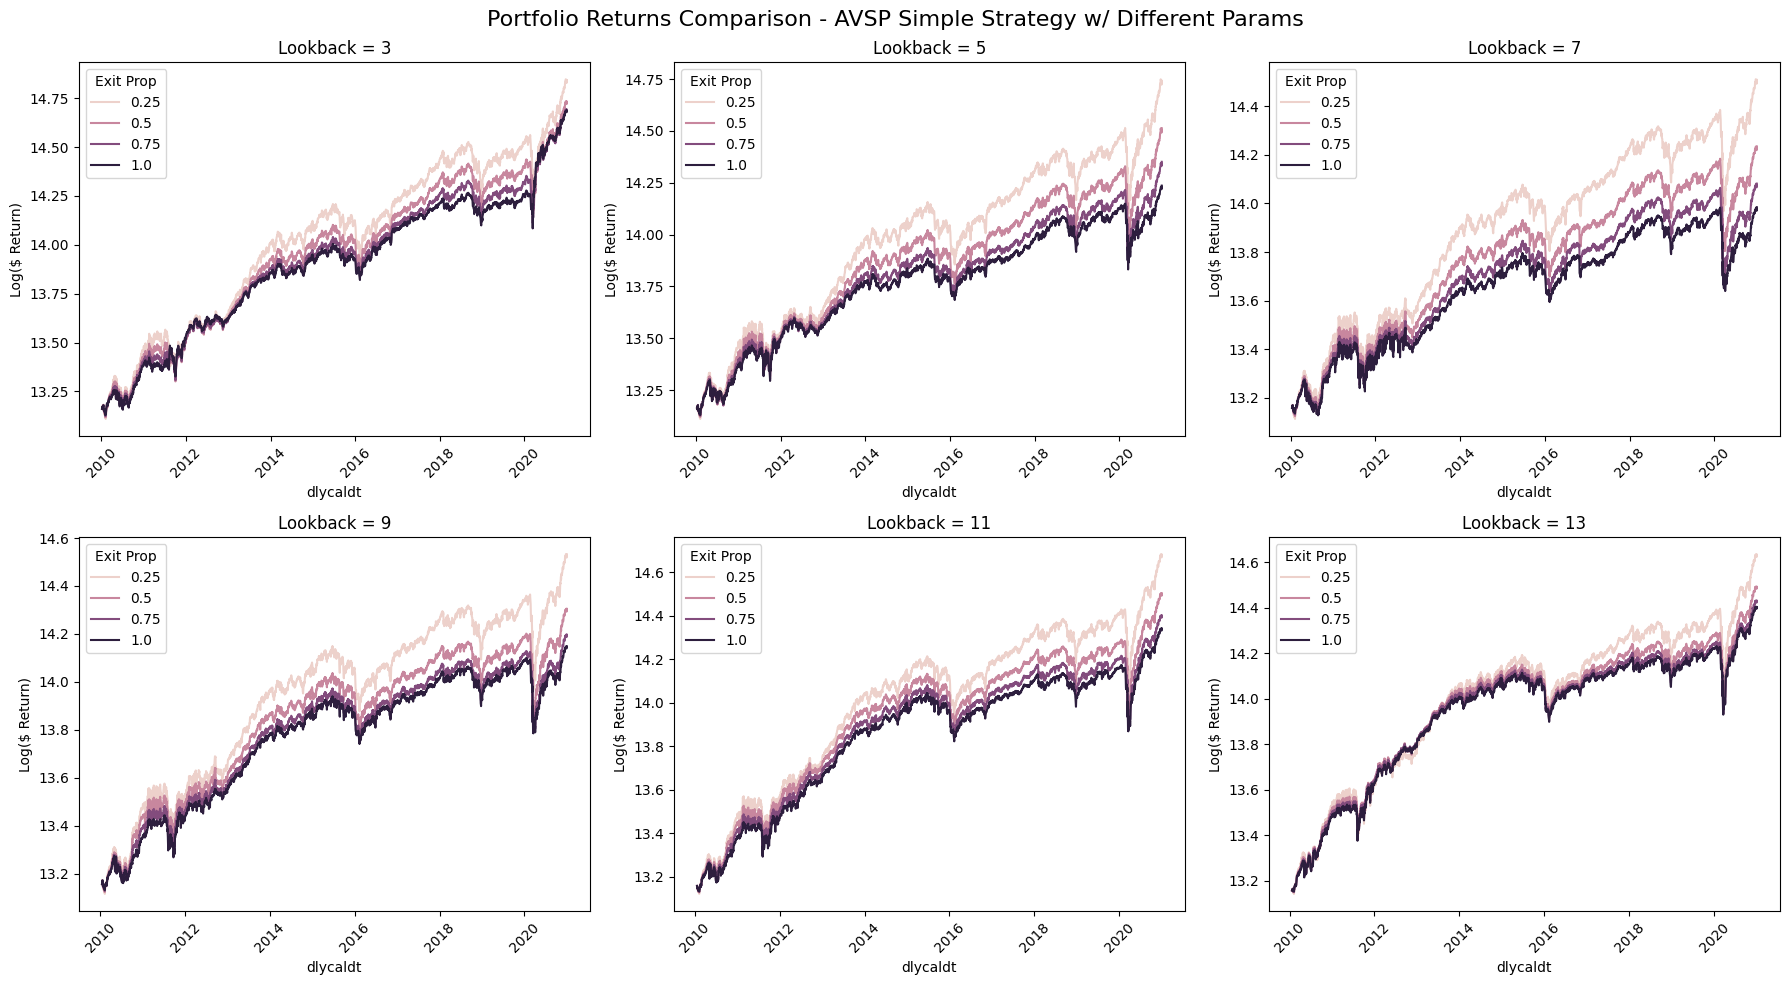

In [6]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

ax = ax.flatten()

for i in range(len(ax)):
    
    sub_df = plot_df[plot_df['lookback'] == lookbacks[i]]

    sns.lineplot(
        data=sub_df,
        x=DATE_COL,
        y=np.log(sub_df['strat_ret']),
        hue='exit_prop',
        ax=ax[i]
    )

    ax[i].set_title(f'Lookback = {lookbacks[i]}')
    ax[i].set_ylabel('Log($ Return)')
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].legend(title='Exit Prop')

fig.suptitle(
    'Portfolio Returns Comparison - AVSP Simple Strategy w/ Different Params',
    fontsize=16
)

plt.tight_layout()
plt.show()

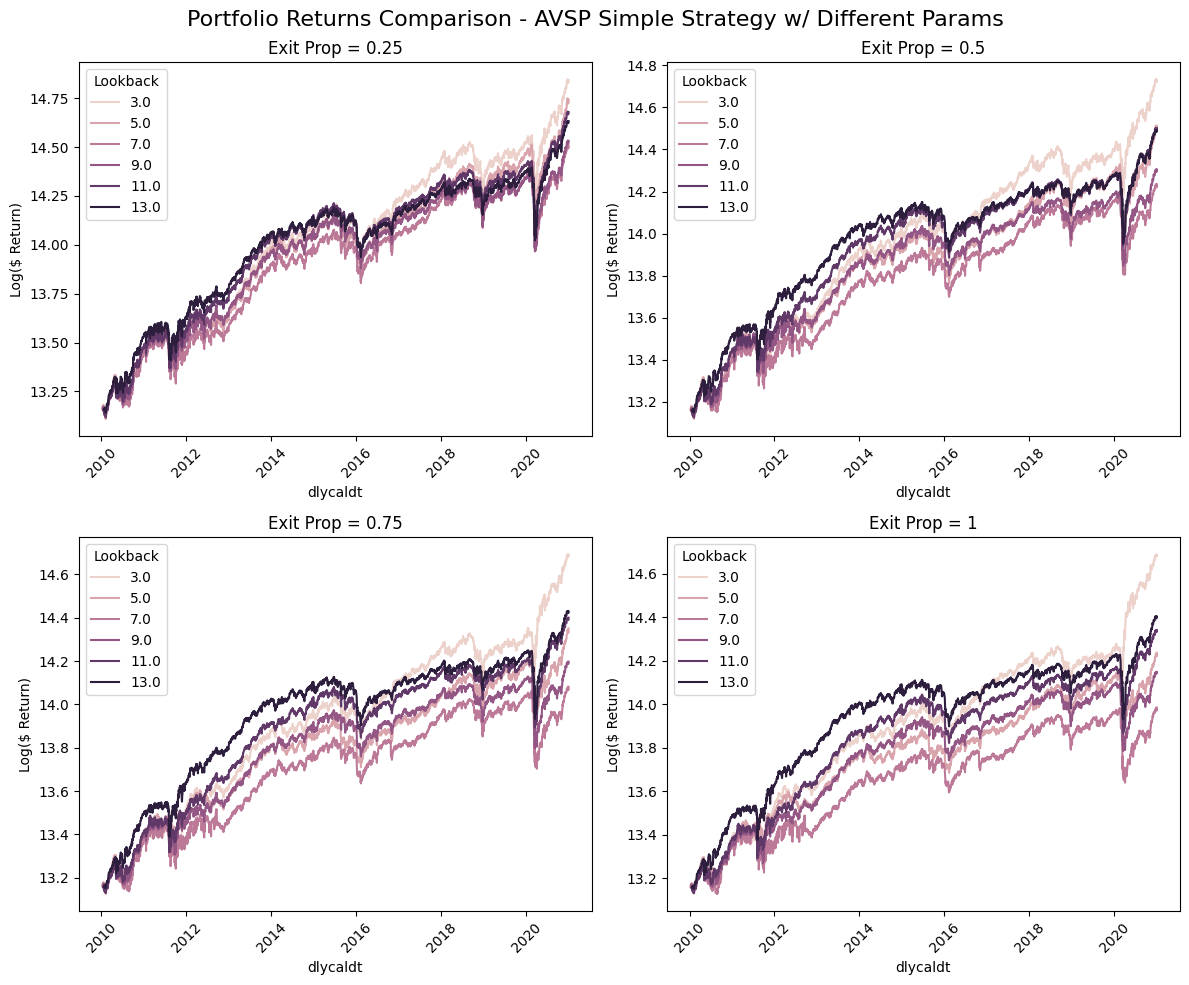

In [7]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

ax = ax.flatten()

for i in range(len(ax)):
    
    sub_df = plot_df[plot_df['exit_prop'] == exit_props[i]]

    sns.lineplot(
        data=sub_df,
        x=DATE_COL,
        y=np.log(sub_df['strat_ret']),
        hue='lookback',
        ax=ax[i]
    )

    ax[i].set_title(f'Exit Prop = {exit_props[i]}')
    ax[i].set_ylabel('Log($ Return)')
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].legend(title='Lookback')

fig.suptitle(
    'Portfolio Returns Comparison - AVSP Simple Strategy w/ Different Params',
    fontsize=16
)

plt.tight_layout()
plt.show()

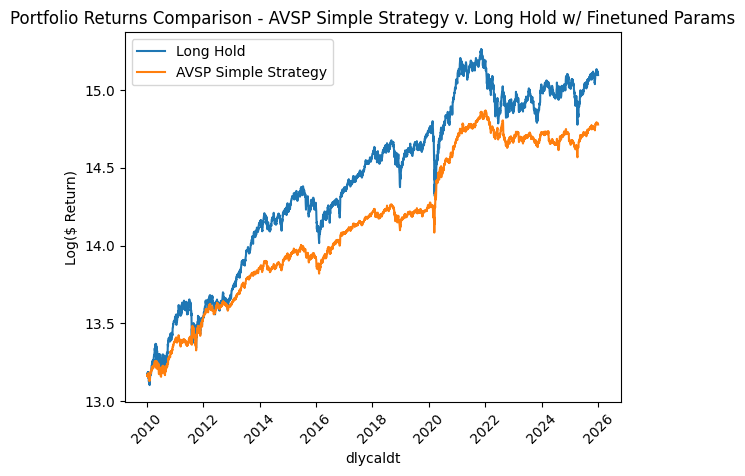

In [9]:
best_lookback = 3
best_p = 1
subplot_df = plot_df[(plot_df['lookback'] == best_lookback) & (plot_df['exit_prop'] == best_p)].reset_index(drop=True)

sns.lineplot(x=subplot_df[DATE_COL], y=np.log(subplot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=subplot_df[DATE_COL], y=np.log(subplot_df['strat_ret']), label="AVSP Simple Strategy")

plt.title("Portfolio Returns Comparison - AVSP Simple Strategy v. Long Hold w/ Finetuned Params")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()